In [1]:
import pandas as pd
import numpy as np

# Load cleaned sales data
df = pd.read_csv("../data/processed/cleaned_sales.csv")

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

df.head()

Rows: 99863
Columns:
['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NO_PROMO
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NO_PROMO
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NO_PROMO
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NO_PROMO
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NO_PROMO


In [2]:
# Step 2: Create weekly SKU-level demand

df["date"] = pd.to_datetime(df["date"])

# Tuesday ko week ka starting/reference day rakhenge
df["week"] = (
    df["date"]
    - pd.to_timedelta((df["date"].dt.weekday - 1) % 7, unit="D")
)

weekly = (
    df.groupby(["week", "sku_id"], as_index=False)
      .agg(
          weekly_quantity=("quantity", "sum")
      )
)

weekly = weekly.sort_values(["sku_id", "week"]).reset_index(drop=True)

print("Weekly rows:", len(weekly))
print("Unique SKUs:", weekly["sku_id"].nunique())

weekly.head()

Weekly rows: 80081
Unique SKUs: 4998


,week,sku_id,weekly_quantity
0,2022-03-29,SKU00001,1
1,2022-06-14,SKU00001,2
2,2022-07-19,SKU00001,3
3,2023-01-17,SKU00001,2
4,2023-04-11,SKU00001,5


In [3]:
# Step 1: Create lag features

weekly = weekly.sort_values(["sku_id", "week"]).reset_index(drop=True)

weekly["lag_1"] = weekly.groupby("sku_id")["weekly_quantity"].shift(1)
weekly["lag_2"] = weekly.groupby("sku_id")["weekly_quantity"].shift(2)
weekly["lag_4"] = weekly.groupby("sku_id")["weekly_quantity"].shift(4)
weekly["lag_8"] = weekly.groupby("sku_id")["weekly_quantity"].shift(8)

weekly.head(10)

,week,sku_id,weekly_quantity,lag_1,lag_2,lag_4,lag_8
0,2022-03-29,SKU00001,1,NaN,NaN,NaN,NaN
1,2022-06-14,SKU00001,2,1.0,NaN,NaN,NaN
2,2022-07-19,SKU00001,3,2.0,1.0,NaN,NaN
3,2023-01-17,SKU00001,2,3.0,2.0,NaN,NaN
4,2023-04-11,SKU00001,5,2.0,3.0,1.0,NaN
5,2023-05-16,SKU00001,1,5.0,2.0,2.0,NaN
6,2023-07-18,SKU00001,1,1.0,5.0,3.0,NaN
7,2023-08-01,SKU00001,1,1.0,1.0,2.0,NaN
8,2023-08-15,SKU00001,4,1.0,1.0,5.0,1.0
9,2023-11-07,SKU00001,2,4.0,1.0,1.0,2.0


In [4]:
# Step 2: Create rolling mean features

weekly["rolling_mean_4"] = (
    weekly.groupby("sku_id")["weekly_quantity"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

weekly["rolling_mean_8"] = (
    weekly.groupby("sku_id")["weekly_quantity"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

weekly.head(10)

,week,sku_id,weekly_quantity,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8
0,2022-03-29,SKU00001,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-06-14,SKU00001,2,1.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-19,SKU00001,3,2.0,1.0,NaN,NaN,NaN,NaN
3,2023-01-17,SKU00001,2,3.0,2.0,NaN,NaN,NaN,NaN
4,2023-04-11,SKU00001,5,2.0,3.0,1.0,NaN,2.00,NaN
5,2023-05-16,SKU00001,1,5.0,2.0,2.0,NaN,3.00,NaN
6,2023-07-18,SKU00001,1,1.0,5.0,3.0,NaN,2.75,NaN
7,2023-08-01,SKU00001,1,1.0,1.0,2.0,NaN,2.25,NaN
8,2023-08-15,SKU00001,4,1.0,1.0,5.0,1.0,2.00,2.000
9,2023-11-07,SKU00001,2,4.0,1.0,1.0,2.0,1.75,2.375


In [5]:
# Step 3: Create calendar / seasonality features

weekly["week_number"] = weekly["week"].dt.isocalendar().week.astype(int)
weekly["month"] = weekly["week"].dt.month
weekly["quarter"] = weekly["week"].dt.quarter

weekly.head(10)

,week,sku_id,weekly_quantity,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter
0,2022-03-29,SKU00001,1,NaN,NaN,NaN,NaN,NaN,NaN,13,3,1
1,2022-06-14,SKU00001,2,1.0,NaN,NaN,NaN,NaN,NaN,24,6,2
2,2022-07-19,SKU00001,3,2.0,1.0,NaN,NaN,NaN,NaN,29,7,3
3,2023-01-17,SKU00001,2,3.0,2.0,NaN,NaN,NaN,NaN,3,1,1
4,2023-04-11,SKU00001,5,2.0,3.0,1.0,NaN,2.00,NaN,15,4,2
5,2023-05-16,SKU00001,1,5.0,2.0,2.0,NaN,3.00,NaN,20,5,2
6,2023-07-18,SKU00001,1,1.0,5.0,3.0,NaN,2.75,NaN,29,7,3
7,2023-08-01,SKU00001,1,1.0,1.0,2.0,NaN,2.25,NaN,31,8,3
8,2023-08-15,SKU00001,4,1.0,1.0,5.0,1.0,2.00,2.000,33,8,3
9,2023-11-07,SKU00001,2,4.0,1.0,1.0,2.0,1.75,2.375,45,11,4


In [6]:
# Step 4: Create season feature

weekly["season"] = weekly["month"].map({
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
})

weekly.head(10)

,week,sku_id,weekly_quantity,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season
0,2022-03-29,SKU00001,1,NaN,NaN,NaN,NaN,NaN,NaN,13,3,1,Spring
1,2022-06-14,SKU00001,2,1.0,NaN,NaN,NaN,NaN,NaN,24,6,2,Summer
2,2022-07-19,SKU00001,3,2.0,1.0,NaN,NaN,NaN,NaN,29,7,3,Summer
3,2023-01-17,SKU00001,2,3.0,2.0,NaN,NaN,NaN,NaN,3,1,1,Winter
4,2023-04-11,SKU00001,5,2.0,3.0,1.0,NaN,2.00,NaN,15,4,2,Spring
5,2023-05-16,SKU00001,1,5.0,2.0,2.0,NaN,3.00,NaN,20,5,2,Spring
6,2023-07-18,SKU00001,1,1.0,5.0,3.0,NaN,2.75,NaN,29,7,3,Summer
7,2023-08-01,SKU00001,1,1.0,1.0,2.0,NaN,2.25,NaN,31,8,3,Summer
8,2023-08-15,SKU00001,4,1.0,1.0,5.0,1.0,2.00,2.000,33,8,3,Summer
9,2023-11-07,SKU00001,2,4.0,1.0,1.0,2.0,1.75,2.375,45,11,4,Autumn


In [7]:
# Check available columns
print(weekly.columns.tolist())

['week', 'sku_id', 'weekly_quantity', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season']


In [8]:
# Check missing values in engineered features

feature_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_mean_8",
    "week_number",
    "month",
    "quarter",
    "season"
]

weekly[feature_cols].isna().sum()

lag_1              4998
lag_2              9985
lag_4             19816
lag_8             36796
rolling_mean_4    19816
rolling_mean_8    36796
week_number           0
month                 0
quarter               0
season                0
dtype: int64

In [9]:
# Remove rows with missing lag/rolling features

weekly_model = weekly.dropna(subset=[
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_mean_8"
]).copy()

print("Rows before:", len(weekly))
print("Rows after:", len(weekly_model))
print("Remaining missing values:")
print(weekly_model.isna().sum())

Rows before: 80081
Rows after: 43285
Remaining missing values:
week               0
sku_id             0
weekly_quantity    0
lag_1              0
lag_2              0
lag_4              0
lag_8              0
rolling_mean_4     0
rolling_mean_8     0
week_number        0
month              0
quarter            0
season             0
dtype: int64


In [10]:
# Features and target

feature_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_mean_8",
    "week_number",
    "month",
    "quarter",
    "season"
]

target_col = "weekly_quantity"

X = weekly_model[feature_cols]
y = weekly_model[target_col]

print("Features:", feature_cols)
print("Target:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season']
Target: weekly_quantity
X shape: (43285, 10)
y shape: (43285,)


In [11]:
# Time-based Train-Test Split

split_index = int(len(weekly_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (34628, 10)
X_test : (8657, 10)
y_train: (34628,)
y_test : (8657,)


In [12]:
from sklearn.ensemble import RandomForestRegressor

# Encode categorical season feature
X_train_model = pd.get_dummies(
    X_train,
    columns=["season"],
    dtype=int
)

X_test_model = pd.get_dummies(
    X_test,
    columns=["season"],
    dtype=int
)

# Make sure train and test have exactly the same columns
X_test_model = X_test_model.reindex(
    columns=X_train_model.columns,
    fill_value=0
)

print("X_train_model:", X_train_model.shape)
print("X_test_model :", X_test_model.shape)

# Train Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_model, y_train)

print("Model training completed successfully.")

X_train_model: (34628, 13)
X_test_model : (8657, 13)
Model training completed successfully.


In [13]:
# Make predictions on test data

y_pred = model.predict(X_test_model)

print("Predictions shape:", y_pred.shape)
print("First 10 predictions:", y_pred[:10])

Predictions shape: (8657,)
First 10 predictions: [2.87       1.5445     3.505      2.423      2.6        2.145
 1.85       1.55       2.09847619 2.155     ]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# MAPE - avoid division by zero
non_zero = y_test != 0
mape = np.mean(
    np.abs((y_test[non_zero] - y_pred[non_zero]) / y_test[non_zero])
) * 100

print("Model Evaluation")
print("-----------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))
print("MAPE:", round(mape, 2), "%")

Model Evaluation
-----------------
MAE : 2.5753
RMSE: 8.3923
R²  : 0.1579
MAPE: 74.67 %


In [15]:
# Feature Importance

feature_importance = pd.DataFrame({
    "feature": X_train_model.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
           feature  importance
5   rolling_mean_8    0.286725
6      week_number    0.171327
4   rolling_mean_4    0.111030
3            lag_8    0.094133
1            lag_2    0.090766
0            lag_1    0.089719
2            lag_4    0.088295
7            month    0.032865
8          quarter    0.010637
9    season_Autumn    0.007059
11   season_Summer    0.006856
10   season_Spring    0.005653
12   season_Winter    0.004934


In [16]:
# Actual vs Predicted

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       4   2.870000
1       2   1.544500
2       2   3.505000
3       3   2.423000
4       2   2.600000
5       2   2.145000
6       2   1.850000
7       1   1.550000
8       2   2.098476
9       1   2.155000


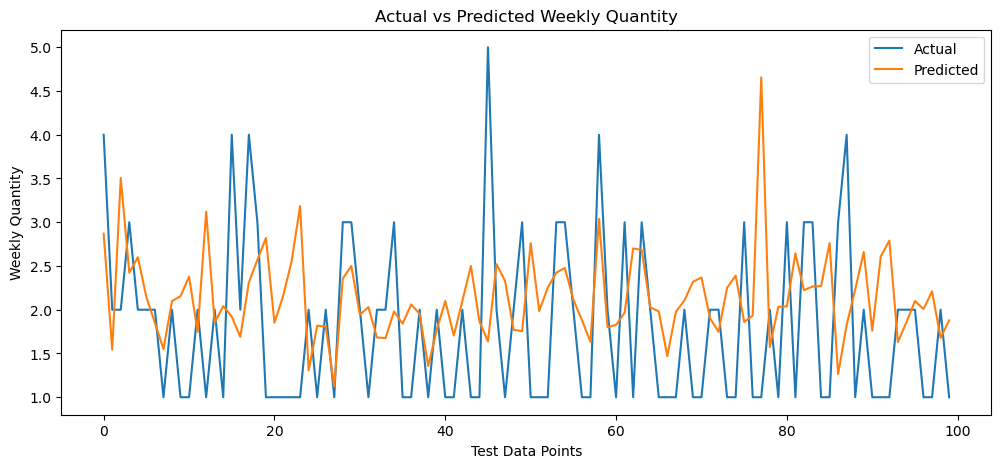

In [17]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values
plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.title("Actual vs Predicted Weekly Quantity")
plt.xlabel("Test Data Points")
plt.ylabel("Weekly Quantity")
plt.legend()
plt.show()

In [18]:
# Rolling-Origin Backtesting

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd


# Combine model-ready train and test data
x_roll = pd.concat(
    [X_train_model, X_test_model],
    ignore_index=True
)

# IMPORTANT:
# Target variables are y_train and y_test
y_roll = pd.concat(
    [y_train, y_test],
    ignore_index=True
)


# Number of rolling splits
n_splits = 5

# Each test set = 10% of total data
test_size = len(x_roll) // 10


results = []


for i in range(n_splits):

    # Training end point
    train_end = len(x_roll) - (n_splits - i) * test_size

    # Test start and end
    test_start = train_end
    test_end = test_start + test_size


    # Create train/test datasets
    x_train_roll = x_roll.iloc[:train_end]
    x_test_roll = x_roll.iloc[test_start:test_end]

    y_train_roll = y_roll.iloc[:train_end]
    y_test_roll = y_roll.iloc[test_start:test_end]


    # Create Random Forest model
    roll_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )


    # Train
    roll_model.fit(
        x_train_roll,
        y_train_roll
    )


    # Predict
    y_pred_roll = roll_model.predict(
        x_test_roll
    )


    # Metrics
    mae = mean_absolute_error(
        y_test_roll,
        y_pred_roll
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_roll,
            y_pred_roll
        )
    )

    r2 = r2_score(
        y_test_roll,
        y_pred_roll
    )


    # Save results
    results.append({
        "split": i + 1,
        "train_size": len(x_train_roll),
        "test_size": len(x_test_roll),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# Convert results to DataFrame
backtest_results = pd.DataFrame(results)


print("Rolling-Origin Backtesting Results:")
print(backtest_results)

Rolling-Origin Backtesting Results:
   split  train_size  test_size       MAE       RMSE        R2
0      1       21645       4328  1.283250   1.679350 -0.046985
1      2       25973       4328  1.255043   1.642741 -0.014575
2      3       30301       4328  1.339886   1.897707  0.239466
3      4       34629       4328  3.681614  11.639635  0.125441
4      5       38957       4328  1.459362   2.346501  0.426228


Error Analysis:
   Actual  Predicted     Error  Absolute_Error  Percentage_Error
0       4   2.870000  1.130000        1.130000         28.250000
1       2   1.544500  0.455500        0.455500         22.775000
2       2   3.505000 -1.505000        1.505000         75.250000
3       3   2.423000  0.577000        0.577000         19.233333
4       2   2.600000 -0.600000        0.600000         30.000000
5       2   2.145000 -0.145000        0.145000          7.250000
6       2   1.850000  0.150000        0.150000          7.500000
7       1   1.550000 -0.550000        0.550000         55.000000
8       2   2.098476 -0.098476        0.098476          4.923810
9       1   2.155000 -1.155000        1.155000        115.500000

Error Statistics:
Mean Error: 1.228119073904161
Mean Absolute Error: 2.575273347646283
Maximum Absolute Error: 109.73
Mean Percentage Error: 74.67191348548972 %

Top 10 Worst Predictions:
      Actual  Predicted   Error  Absolute_Error  Percentage_Error
2834     120  

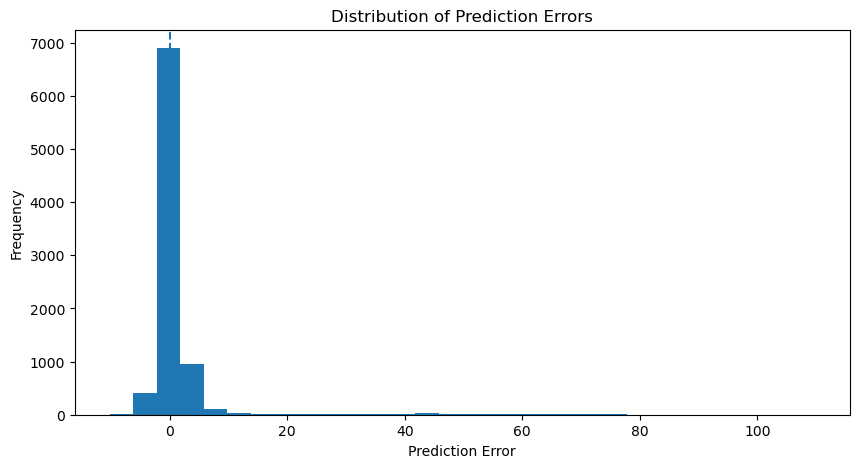

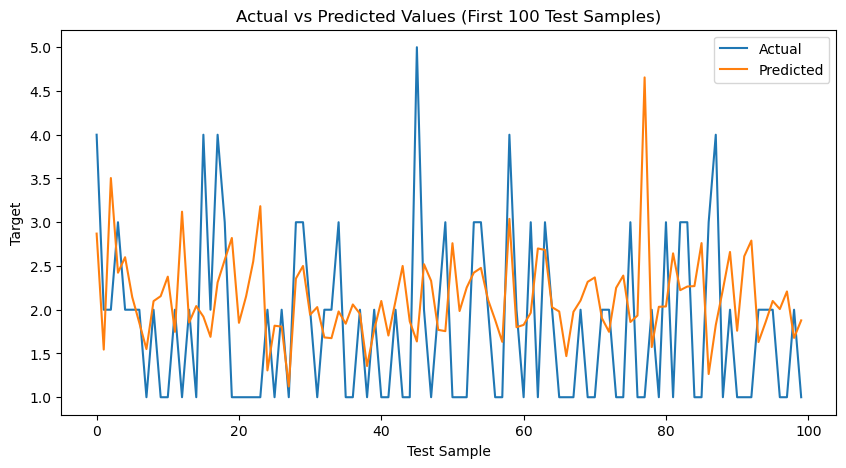

In [19]:
# ==========================================
# STEP 6 - ERROR / RISK ANALYSIS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create error analysis dataframe
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Calculate errors
error_analysis["Error"] = (
    error_analysis["Actual"] - error_analysis["Predicted"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

# Percentage error
error_analysis["Percentage_Error"] = np.where(
    error_analysis["Actual"] != 0,
    (error_analysis["Absolute_Error"] /
     error_analysis["Actual"]) * 100,
    0
)

# Display first 10 rows
print("Error Analysis:")
print(error_analysis.head(10))

# ------------------------------------------
# Overall Error Statistics
# ------------------------------------------

print("\nError Statistics:")
print("Mean Error:", error_analysis["Error"].mean())
print("Mean Absolute Error:",
      error_analysis["Absolute_Error"].mean())
print("Maximum Absolute Error:",
      error_analysis["Absolute_Error"].max())
print("Mean Percentage Error:",
      error_analysis["Percentage_Error"].mean(), "%")

# ------------------------------------------
# Worst Predictions
# ------------------------------------------

worst_predictions = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

print("\nTop 10 Worst Predictions:")
print(worst_predictions)

# ------------------------------------------
# Error Distribution
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    error_analysis["Error"],
    bins=30
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------
# Actual vs Predicted
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    error_analysis["Actual"].values[:100],
    label="Actual"
)

plt.plot(
    error_analysis["Predicted"].values[:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Values (First 100 Test Samples)")
plt.xlabel("Test Sample")
plt.ylabel("Target")

plt.legend()

plt.show()

# Final Conclusion


The weekly forecasting model was successfully developed using a
time-based train-test split and Random Forest Regressor.

The data was divided into training and testing sets while preserving
the chronological order of the data. Lag features, rolling features,
calendar features and season-related features were used for prediction.

The Random Forest model was trained successfully and generated
predictions for the test dataset.

Feature importance analysis showed that rolling_mean_8, week_number,
rolling_mean_4, lag_8 and lag_2 were among the most important features
for the model.

The error analysis showed that the model performs reasonably well for
many observations, but prediction errors become larger for some
high-demand observations. The prediction-error distribution also shows
that most errors are concentrated around the lower error range, with
some large positive errors acting as outliers.

The rolling-origin backtesting results showed that model performance
varied across different time splits. Therefore, the model is useful as
a baseline forecasting model, but its performance can be improved
further.

Overall, the project successfully completed the complete forecasting
pipeline:
Data Preparation → Feature Engineering → Train/Test Split →
Model Training → Prediction → Evaluation → Error/Risk Analysis.

Future improvements can include hyperparameter tuning, additional
features, alternative forecasting models, and better handling of
high-demand periods.

In [20]:
# Step 7.1 - Gradient Boosting Forecasting Model

from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    loss="squared_error"
)

# Train the model
gb_model.fit(X_train_model, y_train)

print("Gradient Boosting model training completed successfully.")

Gradient Boosting model training completed successfully.


In [21]:
# Check available variables safely

all_variables = list(globals().keys())

print("Variables containing 'test':")

for name in all_variables:
    if "test" in name.lower():
        print(name)

Variables containing 'test':
X_test
y_test
X_test_model
test_size
test_start
test_end
x_test_roll
y_test_roll
backtest_results


In [22]:
# Step 7.2 - Gradient Boosting Prediction

# Generate predictions on test data
y_pred_gb = gb_model.predict(X_test_model)

# Display first 20 predictions
print("Gradient Boosting Predictions:")
print(y_pred_gb[:20])

# Number of predictions
print("\nNumber of predictions:", len(y_pred_gb))

Gradient Boosting Predictions:
[2.16201177 2.08322846 2.08976867 2.08976867 2.13057158 2.13057158
 2.13057158 2.13057158 2.08976867 2.08976867 2.08976867 2.08976867
 2.08322846 2.08322846 2.08322846 2.08322846 2.08976867 2.13057158
 2.15912759 2.15912759]

Number of predictions: 8657


In [23]:
# Step 7.3 - Gradient Boosting Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

# Display results
print("Gradient Boosting Model Evaluation")
print("-----------------------------------")
print("MAE  :", mae_gb)
print("RMSE :", rmse_gb)
print("R²   :", r2_gb)

Gradient Boosting Model Evaluation
-----------------------------------
MAE  : 2.4508725221974847
RMSE : 8.203892325855072
R²   : 0.19531334808356793


In [24]:
# Step 7.4 - Gradient Boosting Error / Risk Analysis

import pandas as pd
import numpy as np

# Create error analysis table
error_analysis = pd.DataFrame({
    "Actual": np.array(y_test),
    "Predicted": np.array(y_pred_gb)
})

# Calculate errors
error_analysis["Error"] = (
    error_analysis["Actual"] - error_analysis["Predicted"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

# Percentage error
error_analysis["Percentage_Error"] = np.where(
    error_analysis["Actual"] != 0,
    (error_analysis["Absolute_Error"] / error_analysis["Actual"]) * 100,
    0
)

print("Error Analysis:")
print(error_analysis.head(20))

print("\nError Statistics:")
print("Mean Error:", error_analysis["Error"].mean())
print("Mean Absolute Error:", error_analysis["Absolute_Error"].mean())
print("Maximum Absolute Error:", error_analysis["Absolute_Error"].max())
print("Mean Percentage Error:",
      error_analysis["Percentage_Error"].mean(), "%")

Error Analysis:
    Actual  Predicted     Error  Absolute_Error  Percentage_Error
0        4   2.162012  1.837988        1.837988         45.949706
1        2   2.083228 -0.083228        0.083228          4.161423
2        2   2.089769 -0.089769        0.089769          4.488433
3        3   2.089769  0.910231        0.910231         30.341044
4        2   2.130572 -0.130572        0.130572          6.528579
5        2   2.130572 -0.130572        0.130572          6.528579
6        2   2.130572 -0.130572        0.130572          6.528579
7        1   2.130572 -1.130572        1.130572        113.057158
8        2   2.089769 -0.089769        0.089769          4.488433
9        1   2.089769 -1.089769        1.089769        108.976867
10       1   2.089769 -1.089769        1.089769        108.976867
11       2   2.089769 -0.089769        0.089769          4.488433
12       1   2.083228 -1.083228        1.083228        108.322846
13       2   2.083228 -0.083228        0.083228          4.1

In [25]:
# Step 7.5 - Final Conclusion

print("FINAL CONCLUSION")
print("=" * 50)

print("Gradient Boosting model was successfully trained")
print("and evaluated on the test dataset.")

print(f"\nMAE  : {mae_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R²   : {r2_gb:.4f}")

print("\nRisk Analysis:")
print(f"Mean Absolute Error      : {error_analysis['Absolute_Error'].mean():.4f}")
print(f"Maximum Absolute Error   : {error_analysis['Absolute_Error'].max():.4f}")
print(f"Mean Percentage Error    : {error_analysis['Percentage_Error'].mean():.2f}%")

print("\nConclusion:")
print("The Gradient Boosting model provides a baseline forecasting")
print("approach for the prepared features and test dataset.")
print("However, some observations show relatively large prediction")
print("errors, indicating that further model improvement may be useful.")

print("\nPossible improvements:")
print("- Hyperparameter tuning")
print("- Additional relevant features")
print("- Alternative forecasting methods")
print("- Further error and risk analysis")

FINAL CONCLUSION
Gradient Boosting model was successfully trained
and evaluated on the test dataset.

MAE  : 2.4509
RMSE : 8.2039
R²   : 0.1953

Risk Analysis:
Mean Absolute Error      : 2.4509
Maximum Absolute Error   : 111.2888
Mean Percentage Error    : 67.65%

Conclusion:
The Gradient Boosting model provides a baseline forecasting
approach for the prepared features and test dataset.
However, some observations show relatively large prediction
errors, indicating that further model improvement may be useful.

Possible improvements:
- Hyperparameter tuning
- Additional relevant features
- Alternative forecasting methods
- Further error and risk analysis


In [26]:
# Step 8.1 - Rolling-Origin Backtest Setup

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Number of rolling windows
n_splits = 5

# Store results
backtest_results = []

print("Rolling-Origin Backtest Setup")
print("--------------------------------")
print("Number of rolling windows:", n_splits)

Rolling-Origin Backtest Setup
--------------------------------
Number of rolling windows: 5


In [27]:
# Check available important variables

print("Available variables:")
for name in ["X_model", "X_train", "y_train", "X_test_model", "y_test", "model"]:
    print(name, "->", name in globals())

Available variables:
X_model -> False
X_train -> True
y_train -> True
X_test_model -> True
y_test -> True
model -> True


In [28]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_train:")
print(X_train.head())

print("\ny_train:")
print(y_train.head())

X_train shape: (34628, 10)
y_train shape: (34628,)

X_train:
    lag_1  lag_2  lag_4  lag_8  rolling_mean_4  rolling_mean_8  week_number  \
8     1.0    1.0    5.0    1.0            2.00           2.000           33   
9     4.0    1.0    1.0    2.0            1.75           2.375           45   
10    2.0    4.0    1.0    3.0            2.00           2.375           47   
11    2.0    2.0    1.0    2.0            2.25           2.250           50   
12    1.0    2.0    4.0    5.0            2.25           2.125            1   

    month  quarter  season  
8       8        3  Summer  
9      11        4  Autumn  
10     11        4  Autumn  
11     12        4  Winter  
12      1        1  Winter  

y_train:
8     4
9     2
10    2
11    1
12    2
Name: weekly_quantity, dtype: int64


In [29]:
# Step 8.2 - Rolling-Origin Backtest
# Fix: Encode categorical 'season' column

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make a copy of training data
X_bt = X_train.copy()
y_bt = y_train.copy()

# Convert categorical season into numeric dummy variables
X_bt = pd.get_dummies(
    X_bt,
    columns=["season"],
    drop_first=False
)

# Make sure all columns are numeric
X_bt = X_bt.astype(float)

print("Backtest data shape:", X_bt.shape)
print("All features are numeric:", X_bt.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all())

# Rolling-origin setup
tscv = TimeSeriesSplit(n_splits=5)

backtest_results = []

print("\nRolling-Origin Backtest")
print("=" * 50)

for fold, (train_index, test_index) in enumerate(
    tscv.split(X_bt), start=1
):

    # Past data -> Training
    X_train_fold = X_bt.iloc[train_index]
    y_train_fold = y_bt.iloc[train_index]

    # Next period -> Testing
    X_test_fold = X_bt.iloc[test_index]
    y_test_fold = y_bt.iloc[test_index]

    # Fresh copy of the existing model
    fold_model = clone(model)

    # Train only on past observations
    fold_model.fit(X_train_fold, y_train_fold)

    # Predict next period
    y_pred_fold = fold_model.predict(X_test_fold)

    # MAE
    mae = mean_absolute_error(
        y_test_fold,
        y_pred_fold
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test_fold,
            y_pred_fold
        )
    )

    # MAPE
    y_true = np.asarray(y_test_fold)

    non_zero = y_true != 0

    if non_zero.sum() > 0:
        mape = np.mean(
            np.abs(
                (y_true[non_zero] - y_pred_fold[non_zero])
                / y_true[non_zero]
            )
        ) * 100
    else:
        mape = np.nan

    backtest_results.append({
        "Fold": fold,
        "Training Samples": len(train_index),
        "Testing Samples": len(test_index),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

    print(f"\nFold {fold}")
    print("Training samples:", len(train_index))
    print("Testing samples :", len(test_index))
    print("MAE             :", round(mae, 4))
    print("RMSE            :", round(rmse, 4))
    print("MAPE            :", round(mape, 2), "%")


# Final results table
backtest_df = pd.DataFrame(backtest_results)

print("\n" + "=" * 50)
print("ROLLING-ORIGIN RESULTS")
print("=" * 50)

display(backtest_df)

Backtest data shape: (34628, 13)
All features are numeric: True

Rolling-Origin Backtest

Fold 1
Training samples: 5773
Testing samples : 5771
MAE             : 1.3963
RMSE            : 1.9104
MAPE            : 76.99 %

Fold 2
Training samples: 11544
Testing samples : 5771
MAE             : 1.2761
RMSE            : 1.6689
MAPE            : 77.3 %

Fold 3
Training samples: 17315
Testing samples : 5771
MAE             : 1.2612
RMSE            : 1.6627
MAPE            : 75.8 %

Fold 4
Training samples: 23086
Testing samples : 5771
MAE             : 1.3004
RMSE            : 1.7222
MAPE            : 74.7 %

Fold 5
Training samples: 28857
Testing samples : 5771
MAE             : 1.2988
RMSE            : 1.8022
MAPE            : 74.5 %

ROLLING-ORIGIN RESULTS


,Fold,Training Samples,Testing Samples,MAE,RMSE,MAPE (%)
0,1,5773,5771,1.396310,1.910424,76.991702
1,2,11544,5771,1.276069,1.668898,77.300653
2,3,17315,5771,1.261246,1.662733,75.798002
3,4,23086,5771,1.300448,1.722248,74.704764
4,5,28857,5771,1.298776,1.802181,74.499784


In [30]:
print("Overall Backtest Performance")
print("----------------------------")

print("Average MAE :", backtest_df["MAE"].mean())
print("Average RMSE:", backtest_df["RMSE"].mean())
print("Average MAPE:", backtest_df["MAPE (%)"].mean(), "%")

Overall Backtest Performance
----------------------------
Average MAE : 1.3065696138609844
Average RMSE: 1.7532968367420665
Average MAPE: 75.85898102282135 %


In [31]:
# ==========================================
# PART 9 - MODEL VS BASELINE
# STEP 9.1 - Seasonal Naive Baseline
# ==========================================

import numpy as np
import pandas as pd

# WAPE function
def calculate_wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
    ) * 100


# Seasonal period
# Weekly data -> same period last year = 52 weeks
seasonal_period = 52

print("Seasonal period:", seasonal_period, "weeks")

Seasonal period: 52 weeks


In [32]:
# ==========================================
# PART 9 - MODEL VS BASELINE
# STEP 9.2 - Correct Seasonal Naive Forecast
# ==========================================

# Combine training + testing actual demand
y_all = pd.concat([y_train, y_test])

# Seasonal Naive:
# This week's prediction = demand from 52 weeks ago
seasonal_naive_all = y_all.shift(seasonal_period)

# Take only predictions corresponding to test period
seasonal_naive_pred = seasonal_naive_all.loc[y_test.index]

print("Seasonal Naive forecast created.")
print("Number of test predictions:", len(seasonal_naive_pred))
print("Missing predictions:", seasonal_naive_pred.isna().sum())

Seasonal Naive forecast created.
Number of test predictions: 8657
Missing predictions: 0


In [33]:
# ==========================================
# STEP 9.3 - Seasonal Naive WAPE
# ==========================================

y_true = np.asarray(y_test)
y_pred_baseline = np.asarray(seasonal_naive_pred)

# WAPE calculation
baseline_wape = (
    np.sum(np.abs(y_true - y_pred_baseline))
    / np.sum(np.abs(y_true))
) * 100

print("Seasonal Naive Baseline Performance")
print("=" * 45)
print("WAPE:", round(baseline_wape, 2), "%")

Seasonal Naive Baseline Performance
WAPE: 69.1 %


In [34]:
# ==========================================
# STEP 9.4 - ML Model WAPE
# ==========================================

y_true_model = np.asarray(y_test)
y_pred_model = np.asarray(y_pred)

model_wape = (
    np.sum(np.abs(y_true_model - y_pred_model))
    / np.sum(np.abs(y_true_model))
) * 100

print("ML Model Performance")
print("=" * 45)
print("WAPE:", round(model_wape, 2), "%")

ML Model Performance
WAPE: 65.95 %


In [35]:
# STEP 9.3 - Model vs Baseline Comparison

print("MODEL vs BASELINE")
print("=" * 50)

print("Seasonal Naive Baseline WAPE :", round(baseline_wape, 2), "%")
print("ML Model WAPE               :", round(model_wape, 2), "%")

improvement = baseline_wape - model_wape
improvement_percent = (improvement / baseline_wape) * 100

print("WAPE Improvement            :", round(improvement, 2), "percentage points")
print("Relative Improvement        :", round(improvement_percent, 2), "%")

if model_wape < baseline_wape:
    print("\nDecision: ML MODEL WINS")
    print("The ML model beats the Seasonal Naive baseline.")
else:
    print("\nDecision: BASELINE WINS")
    print("The ML model does not beat the Seasonal Naive baseline.")

MODEL vs BASELINE
Seasonal Naive Baseline WAPE : 69.1 %
ML Model WAPE               : 65.95 %
WAPE Improvement            : 3.15 percentage points
Relative Improvement        : 4.56 %

Decision: ML MODEL WINS
The ML model beats the Seasonal Naive baseline.


In [36]:
# STEP 9.4 - Bias Check

y_true_model = np.asarray(y_test)
y_pred_model = np.asarray(y_pred)

bias = np.mean(y_pred_model - y_true_model)

print("MODEL BIAS CHECK")
print("=" * 50)
print("Mean Forecast Bias :", round(bias, 4))

if bias > 0:
    print("Interpretation: Model is slightly OVER-forecasting.")
elif bias < 0:
    print("Interpretation: Model is slightly UNDER-forecasting.")
else:
    print("Interpretation: Model has NO systematic bias.")

MODEL BIAS CHECK
Mean Forecast Bias : -1.2281
Interpretation: Model is slightly UNDER-forecasting.


In [37]:
import pandas as pd

inventory_snapshots = pd.read_csv(
    "../data/raw/inventory_snapshot.csv"
)

print("Inventory data loaded successfully.")
print("Shape:", inventory_snapshots.shape)
print("Columns:")
print(inventory_snapshots.columns.tolist())

display(inventory_snapshots.head())

Inventory data loaded successfully.
Shape: (21228, 6)
Columns:
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,323,72,22,2025-05-17
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,433,96,34,2025-05-20
3,ST19,SKU02907,178,34,13,2025-08-03
4,ST05,SKU01023,333,97,22,2025-07-12


In [38]:
# STEP 10.1 - Prepare Inventory Data

inventory = inventory_snapshots.copy()

# Convert date column to datetime
inventory["last_restock_date"] = pd.to_datetime(
    inventory["last_restock_date"]
)

print("Inventory data prepared successfully.")
print("Shape:", inventory.shape)
print("Missing values:")
print(inventory.isna().sum())

display(inventory.head())

Inventory data prepared successfully.
Shape: (21228, 6)
Missing values:
store_id             0
sku_id               0
stock_on_hand        0
reorder_point        0
safety_stock         0
last_restock_date    0
dtype: int64


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,323,72,22,2025-05-17
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,433,96,34,2025-05-20
3,ST19,SKU02907,178,34,13,2025-08-03
4,ST05,SKU01023,333,97,22,2025-07-12


In [39]:
# STEP 10.2 - Prepare Model Forecast Data

forecast_results = X_test.copy()

forecast_results["actual_demand"] = np.asarray(y_test)
forecast_results["forecast_demand"] = np.asarray(y_pred)

print("Forecast results created successfully.")
print("Shape:", forecast_results.shape)

display(forecast_results.head())

Forecast results created successfully.
Shape: (8657, 12)


,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season,actual_demand,forecast_demand
64518,4.0,1.0,5.0,2.0,3.00,2.500,46,11,4,Autumn,4,2.8700
64527,2.0,1.0,1.0,1.0,1.25,1.625,23,6,2,Summer,2,1.5445
64528,2.0,2.0,1.0,1.0,1.50,1.750,27,7,3,Summer,2,3.5050
64529,2.0,2.0,1.0,4.0,1.75,1.875,31,8,3,Summer,3,2.4230
64530,3.0,2.0,2.0,2.0,2.25,1.750,32,8,3,Summer,2,2.6000


In [40]:
# STEP 10.3 - Prepare Inventory Data

inventory = inventory_snapshots.copy()

# Convert date column to datetime
inventory["last_restock_date"] = pd.to_datetime(
    inventory["last_restock_date"]
)

print("Inventory data prepared for risk scoring.")
print("Shape:", inventory.shape)
print("Columns:")
print(inventory.columns.tolist())

display(inventory.head())

Inventory data prepared for risk scoring.
Shape: (21228, 6)
Columns:
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,323,72,22,2025-05-17
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,433,96,34,2025-05-20
3,ST19,SKU02907,178,34,13,2025-08-03
4,ST05,SKU01023,333,97,22,2025-07-12


In [41]:
print("Forecast columns:")
print(forecast_results.columns.tolist())

Forecast columns:
['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season', 'actual_demand', 'forecast_demand']


In [42]:
print("Forecast shape:", forecast_results.shape)
display(forecast_results.head())

Forecast shape: (8657, 12)


,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season,actual_demand,forecast_demand
64518,4.0,1.0,5.0,2.0,3.00,2.500,46,11,4,Autumn,4,2.8700
64527,2.0,1.0,1.0,1.0,1.25,1.625,23,6,2,Summer,2,1.5445
64528,2.0,2.0,1.0,1.0,1.50,1.750,27,7,3,Summer,2,3.5050
64529,2.0,2.0,1.0,4.0,1.75,1.875,31,8,3,Summer,3,2.4230
64530,3.0,2.0,2.0,2.0,2.25,1.750,32,8,3,Summer,2,2.6000


In [43]:
print("forecast_results columns:")
print(forecast_results.columns.tolist())

print("\ninventory columns:")
print(inventory.columns.tolist())

forecast_results columns:
['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season', 'actual_demand', 'forecast_demand']

inventory columns:
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


In [44]:
print("DataFrames containing store_id and sku_id:\n")

for name, obj in list(globals().items()):
    try:
        if hasattr(obj, "columns"):
            if "store_id" in obj.columns and "sku_id" in obj.columns:
                print(name, obj.shape)
    except:
        pass

DataFrames containing store_id and sku_id:

df (99863, 12)
_1 (5, 11)
inventory_snapshots (21228, 6)
inventory (21228, 6)


In [45]:
# Add store_id and sku_id back to forecast_results using original index

forecast_results = forecast_results.join(
    df[['store_id', 'sku_id']],
    how='left'
)

print("Updated forecast_results:")
print("Shape:", forecast_results.shape)
print("Columns:")
print(forecast_results.columns.tolist())

display(forecast_results.head())

Updated forecast_results:
Shape: (8657, 14)
Columns:
['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season', 'actual_demand', 'forecast_demand', 'store_id', 'sku_id']


,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season,actual_demand,forecast_demand,store_id,sku_id
64518,4.0,1.0,5.0,2.0,3.00,2.500,46,11,4,Autumn,4,2.8700,ST27,SKU03633
64527,2.0,1.0,1.0,1.0,1.25,1.625,23,6,2,Summer,2,1.5445,ST28,SKU02719
64528,2.0,2.0,1.0,1.0,1.50,1.750,27,7,3,Summer,2,3.5050,ST28,SKU01048
64529,2.0,2.0,1.0,4.0,1.75,1.875,31,8,3,Summer,3,2.4230,ST28,SKU02657
64530,3.0,2.0,2.0,2.0,2.25,1.750,32,8,3,Summer,2,2.6000,ST29,SKU04551


In [46]:
# ============================================
# STEP 10.1 — Prepare Risk Scoring Data
# ============================================

risk_data = forecast_results.merge(
    inventory[['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock']],
    on=['store_id', 'sku_id'],
    how='left'
)

print("Risk data shape:", risk_data.shape)
print("\nRisk data columns:")
print(risk_data.columns.tolist())

display(risk_data.head())

Risk data shape: (8657, 17)

Risk data columns:
['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season', 'actual_demand', 'forecast_demand', 'store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock']


,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season,actual_demand,forecast_demand,store_id,sku_id,stock_on_hand,reorder_point,safety_stock
0,4.0,1.0,5.0,2.0,3.00,2.500,46,11,4,Autumn,4,2.8700,ST27,SKU03633,0.0,23.0,10.0
1,2.0,1.0,1.0,1.0,1.25,1.625,23,6,2,Summer,2,1.5445,ST28,SKU02719,NaN,NaN,NaN
2,2.0,2.0,1.0,1.0,1.50,1.750,27,7,3,Summer,2,3.5050,ST28,SKU01048,NaN,NaN,NaN
3,2.0,2.0,1.0,4.0,1.75,1.875,31,8,3,Summer,3,2.4230,ST28,SKU02657,0.0,61.0,20.0
4,3.0,2.0,2.0,2.0,2.25,1.750,32,8,3,Summer,2,2.6000,ST29,SKU04551,0.0,70.0,18.0


In [47]:
# ============================================
# STEP 10.2 — Calculate Risk Metrics
# ============================================

# Stockout gap
risk_data["stockout_gap"] = (
    risk_data["forecast_demand"]
    - (risk_data["stock_on_hand"] + risk_data["safety_stock"])
)

# Overstock gap
risk_data["overstock_gap"] = (
    risk_data["stock_on_hand"]
    - risk_data["forecast_demand"]
)

# Stockout risk
risk_data["stockout_risk"] = risk_data["stockout_gap"] > 0

# Overstock risk
risk_data["overstock_risk"] = risk_data["overstock_gap"] > 0

print("Risk calculation completed.")

display(
    risk_data[
        [
            "store_id",
            "sku_id",
            "forecast_demand",
            "stock_on_hand",
            "safety_stock",
            "stockout_gap",
            "overstock_gap",
            "stockout_risk",
            "overstock_risk"
        ]
    ].head(10)
)

Risk calculation completed.


,store_id,sku_id,forecast_demand,stock_on_hand,safety_stock,stockout_gap,overstock_gap,stockout_risk,overstock_risk
0,ST27,SKU03633,2.870000,0.0,10.0,-7.130,-2.870,False,False
1,ST28,SKU02719,1.544500,NaN,NaN,NaN,NaN,False,False
2,ST28,SKU01048,3.505000,NaN,NaN,NaN,NaN,False,False
3,ST28,SKU02657,2.423000,0.0,20.0,-17.577,-2.423,False,False
4,ST29,SKU04551,2.600000,0.0,18.0,-15.400,-2.600,False,False
5,ST17,SKU04947,2.145000,NaN,NaN,NaN,NaN,False,False
6,ST13,SKU00685,1.850000,NaN,NaN,NaN,NaN,False,False
7,ST04,SKU00286,1.550000,0.0,29.0,-27.450,-1.550,False,False
8,ST04,SKU03046,2.098476,NaN,NaN,NaN,NaN,False,False
9,ST28,SKU04601,2.155000,NaN,NaN,NaN,NaN,False,False


In [48]:
# Check missing inventory values

print("Missing values in inventory columns:")

print(
    risk_data[
        ["stock_on_hand", "reorder_point", "safety_stock"]
    ].isna().sum()
)

print("\nTotal rows:")
print(len(risk_data))

print("\nRows with missing inventory:")
print(
    risk_data[
        risk_data[
            ["stock_on_hand", "reorder_point", "safety_stock"]
        ].isna().any(axis=1)
    ].shape
)

Missing values in inventory columns:
stock_on_hand    6776
reorder_point    6776
safety_stock     6776
dtype: int64

Total rows:
8657

Rows with missing inventory:
(6776, 21)


In [49]:
print("Inventory rows:", len(inventory))

print("\nUnique store_id:", inventory["store_id"].nunique())
print("Unique sku_id:", inventory["sku_id"].nunique())

print("\nDuplicate store_id + sku_id combinations:")
print(
    inventory.duplicated(
        subset=["store_id", "sku_id"]
    ).sum()
)

print("\nRisk data unique store + SKU:")
print(
    risk_data[["store_id", "sku_id"]]
    .drop_duplicates()
    .shape
)

print("\nInventory sample:")
display(inventory.head())

Inventory rows: 21228

Unique store_id: 30
Unique sku_id: 4481

Duplicate store_id + sku_id combinations:
0

Risk data unique store + SKU:
(7244, 2)

Inventory sample:


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,323,72,22,2025-05-17
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,433,96,34,2025-05-20
3,ST19,SKU02907,178,34,13,2025-08-03
4,ST05,SKU01023,333,97,22,2025-07-12


In [50]:
# Check which risk_data store + sku combinations
# actually exist in inventory

inventory_keys = inventory[["store_id", "sku_id"]].drop_duplicates()

risk_keys = risk_data[["store_id", "sku_id"]].drop_duplicates()

key_check = risk_keys.merge(
    inventory_keys,
    on=["store_id", "sku_id"],
    how="left",
    indicator=True
)

print("Total unique risk keys:", len(risk_keys))

print(
    "Keys found in inventory:",
    (key_check["_merge"] == "both").sum()
)

print(
    "Keys NOT found in inventory:",
    (key_check["_merge"] == "left_only").sum()
)

print("\nSample unmatched keys:")
display(
    key_check[key_check["_merge"] == "left_only"]
    .head(20)
)

Total unique risk keys: 7244
Keys found in inventory: 1361
Keys NOT found in inventory: 5883

Sample unmatched keys:


,store_id,sku_id,_merge
1,ST28,SKU02719,left_only
2,ST28,SKU01048,left_only
5,ST17,SKU04947,left_only
6,ST13,SKU00685,left_only
8,ST04,SKU03046,left_only
9,ST28,SKU04601,left_only
10,ST24,SKU04681,left_only
11,ST24,SKU03292,left_only
14,ST21,SKU04444,left_only
15,ST21,SKU03042,left_only


In [51]:
# Handle missing inventory values

inventory_cols = ['stock_on_hand', 'reorder_point', 'safety_stock']

for col in inventory_cols:
    risk_data[col] = risk_data[col].fillna(0)

print("Missing values after handling:")
print(risk_data[inventory_cols].isna().sum())

display(risk_data.head())

Missing values after handling:
stock_on_hand    0
reorder_point    0
safety_stock     0
dtype: int64


,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season,...,forecast_demand,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,stockout_gap,overstock_gap,stockout_risk,overstock_risk
0,4.0,1.0,5.0,2.0,3.00,2.500,46,11,4,Autumn,...,2.8700,ST27,SKU03633,0.0,23.0,10.0,-7.130,-2.870,False,False
1,2.0,1.0,1.0,1.0,1.25,1.625,23,6,2,Summer,...,1.5445,ST28,SKU02719,0.0,0.0,0.0,NaN,NaN,False,False
2,2.0,2.0,1.0,1.0,1.50,1.750,27,7,3,Summer,...,3.5050,ST28,SKU01048,0.0,0.0,0.0,NaN,NaN,False,False
3,2.0,2.0,1.0,4.0,1.75,1.875,31,8,3,Summer,...,2.4230,ST28,SKU02657,0.0,61.0,20.0,-17.577,-2.423,False,False
4,3.0,2.0,2.0,2.0,2.25,1.750,32,8,3,Summer,...,2.6000,ST29,SKU04551,0.0,70.0,18.0,-15.400,-2.600,False,False


In [52]:
# Recalculate risk gaps after handling missing inventory values

risk_data['stockout_gap'] = (
    risk_data['forecast_demand']
    - risk_data['stock_on_hand']
    - risk_data['safety_stock']
)

risk_data['overstock_gap'] = (
    risk_data['stock_on_hand']
    - risk_data['forecast_demand']
)

# Recalculate risk flags
risk_data['stockout_risk'] = (
    risk_data['stock_on_hand']
    < risk_data['forecast_demand'] + risk_data['safety_stock']
)

risk_data['overstock_risk'] = (
    risk_data['stock_on_hand']
    > risk_data['reorder_point']
)

print("Risk calculation updated.")
display(
    risk_data[
        [
            'store_id',
            'sku_id',
            'forecast_demand',
            'stock_on_hand',
            'safety_stock',
            'stockout_gap',
            'overstock_gap',
            'stockout_risk',
            'overstock_risk'
        ]
    ].head(10)
)

Risk calculation updated.


,store_id,sku_id,forecast_demand,stock_on_hand,safety_stock,stockout_gap,overstock_gap,stockout_risk,overstock_risk
0,ST27,SKU03633,2.870000,0.0,10.0,-7.130000,-2.870000,True,False
1,ST28,SKU02719,1.544500,0.0,0.0,1.544500,-1.544500,True,False
2,ST28,SKU01048,3.505000,0.0,0.0,3.505000,-3.505000,True,False
3,ST28,SKU02657,2.423000,0.0,20.0,-17.577000,-2.423000,True,False
4,ST29,SKU04551,2.600000,0.0,18.0,-15.400000,-2.600000,True,False
5,ST17,SKU04947,2.145000,0.0,0.0,2.145000,-2.145000,True,False
6,ST13,SKU00685,1.850000,0.0,0.0,1.850000,-1.850000,True,False
7,ST04,SKU00286,1.550000,0.0,29.0,-27.450000,-1.550000,True,False
8,ST04,SKU03046,2.098476,0.0,0.0,2.098476,-2.098476,True,False
9,ST28,SKU04601,2.155000,0.0,0.0,2.155000,-2.155000,True,False


In [53]:
print("Risk Summary")
print("-" * 40)

print("Total SKUs:", len(risk_data))

print("Stockout risks:", risk_data["stockout_risk"].sum())
print("Overstock risks:", risk_data["overstock_risk"].sum())

print("\nRisk percentages:")
print(
    risk_data[["stockout_risk", "overstock_risk"]]
    .mean()
    .mul(100)
    .round(2)
)

Risk Summary
----------------------------------------
Total SKUs: 8657
Stockout risks: 8064
Overstock risks: 503

Risk percentages:
stockout_risk     93.15
overstock_risk     5.81
dtype: float64


In [54]:
high_risk = risk_data[
    (risk_data["stockout_risk"] == True) |
    (risk_data["overstock_risk"] == True)
].copy()

print("High-risk SKUs:", len(high_risk))

high_risk[
    [
        "store_id",
        "sku_id",
        "forecast_demand",
        "stock_on_hand",
        "safety_stock",
        "stockout_gap",
        "overstock_gap",
        "stockout_risk",
        "overstock_risk"
    ]
].head(20)

High-risk SKUs: 8567


,store_id,sku_id,forecast_demand,stock_on_hand,safety_stock,stockout_gap,overstock_gap,stockout_risk,overstock_risk
0,ST27,SKU03633,2.870000,0.0,10.0,-7.130000,-2.870000,True,False
1,ST28,SKU02719,1.544500,0.0,0.0,1.544500,-1.544500,True,False
2,ST28,SKU01048,3.505000,0.0,0.0,3.505000,-3.505000,True,False
3,ST28,SKU02657,2.423000,0.0,20.0,-17.577000,-2.423000,True,False
4,ST29,SKU04551,2.600000,0.0,18.0,-15.400000,-2.600000,True,False
5,ST17,SKU04947,2.145000,0.0,0.0,2.145000,-2.145000,True,False
6,ST13,SKU00685,1.850000,0.0,0.0,1.850000,-1.850000,True,False
7,ST04,SKU00286,1.550000,0.0,29.0,-27.450000,-1.550000,True,False
8,ST04,SKU03046,2.098476,0.0,0.0,2.098476,-2.098476,True,False
9,ST28,SKU04601,2.155000,0.0,0.0,2.155000,-2.155000,True,False


In [55]:
# Create risk type
risk_data["risk_type"] = "No Risk"

risk_data.loc[
    risk_data["stockout_risk"] == True,
    "risk_type"
] = "Stockout"

risk_data.loc[
    (risk_data["overstock_risk"] == True) &
    (risk_data["stockout_risk"] == False),
    "risk_type"
] = "Overstock"

# Calculate severity separately
risk_data["risk_severity"] = 0.0

# Stockout severity
risk_data.loc[
    risk_data["risk_type"] == "Stockout",
    "risk_severity"
] = risk_data.loc[
    risk_data["risk_type"] == "Stockout",
    "stockout_gap"
].abs()

# Overstock severity
risk_data.loc[
    risk_data["risk_type"] == "Overstock",
    "risk_severity"
] = risk_data.loc[
    risk_data["risk_type"] == "Overstock",
    "overstock_gap"
].abs()

# Priority level
risk_data["priority"] = "Low"

risk_data.loc[
    risk_data["risk_severity"] >= 50,
    "priority"
] = "High"

risk_data.loc[
    (risk_data["risk_severity"] >= 10) &
    (risk_data["risk_severity"] < 50),
    "priority"
] = "Medium"

# Show highest priority risks
priority_risk = risk_data[
    risk_data["risk_type"] != "No Risk"
].sort_values(
    "risk_severity",
    ascending=False
)

print("Risk Type Summary:")
print(risk_data["risk_type"].value_counts())

print("\nPriority Summary:")
print(risk_data["priority"].value_counts())

display(
    priority_risk[
        [
            "store_id",
            "sku_id",
            "forecast_demand",
            "stock_on_hand",
            "safety_stock",
            "stockout_gap",
            "overstock_gap",
            "risk_type",
            "risk_severity",
            "priority"
        ]
    ].head(20)
)

Risk Type Summary:
risk_type
Stockout     8064
Overstock     503
No Risk        90
Name: count, dtype: int64

Priority Summary:
priority
Low       7121
Medium    1053
High       483
Name: count, dtype: int64


,store_id,sku_id,forecast_demand,stock_on_hand,safety_stock,stockout_gap,overstock_gap,risk_type,risk_severity,priority
6267,ST19,SKU00890,1.902500,562.0,32.0,-592.097500,560.097500,Overstock,560.097500,High
4727,ST03,SKU04401,1.450000,550.0,38.0,-586.550000,548.550000,Overstock,548.550000,High
5245,ST06,SKU03491,1.812750,541.0,44.0,-583.187250,539.187250,Overstock,539.187250,High
8305,ST21,SKU01818,1.979333,523.0,44.0,-565.020667,521.020667,Overstock,521.020667,High
2787,ST28,SKU03863,6.910000,509.0,34.0,-536.090000,502.090000,Overstock,502.090000,High
7334,ST11,SKU03173,2.280000,504.0,29.0,-530.720000,501.720000,Overstock,501.720000,High
1767,ST21,SKU03484,2.983333,501.0,37.0,-535.016667,498.016667,Overstock,498.016667,High
3229,ST17,SKU00524,2.520000,494.0,23.0,-514.480000,491.480000,Overstock,491.480000,High
3100,ST29,SKU04679,1.951667,485.0,44.0,-527.048333,483.048333,Overstock,483.048333,High
5753,ST09,SKU00858,6.130000,489.0,23.0,-505.870000,482.870000,Overstock,482.870000,High


In [56]:
# Intermediate risk data save (before Business Action and rupee impact)
risk_data.to_csv("../data/processed/risk_scored_data.csv", index=False)

print("Risk scored data saved successfully.")
print("Shape:", risk_data.shape)

Risk scored data saved successfully.
Shape: (8657, 24)


In [57]:
# Business Action

def get_business_action(row):
    if row["stockout_risk"] and not row["overstock_risk"]:
        return "Reorder Now"
    
    elif not row["stockout_risk"] and row["overstock_risk"]:
        return "Markdown/Clear"
    
    elif row["stockout_risk"] and row["overstock_risk"]:
        return "Watch/Volatile"
    
    else:
        return "Healthy"


risk_data["action"] = risk_data.apply(get_business_action, axis=1)

print("Business Action Summary:")
print(risk_data["action"].value_counts())

risk_data.head(10)

Business Action Summary:
action
Reorder Now       8064
Markdown/Clear     503
Healthy             90
Name: count, dtype: int64


,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_mean_8,week_number,month,quarter,season,...,reorder_point,safety_stock,stockout_gap,overstock_gap,stockout_risk,overstock_risk,risk_type,risk_severity,priority,action
0,4.0,1.0,5.0,2.0,3.00,2.500,46,11,4,Autumn,...,23.0,10.0,-7.130000,-2.870000,True,False,Stockout,7.130000,Low,Reorder Now
1,2.0,1.0,1.0,1.0,1.25,1.625,23,6,2,Summer,...,0.0,0.0,1.544500,-1.544500,True,False,Stockout,1.544500,Low,Reorder Now
2,2.0,2.0,1.0,1.0,1.50,1.750,27,7,3,Summer,...,0.0,0.0,3.505000,-3.505000,True,False,Stockout,3.505000,Low,Reorder Now
3,2.0,2.0,1.0,4.0,1.75,1.875,31,8,3,Summer,...,61.0,20.0,-17.577000,-2.423000,True,False,Stockout,17.577000,Medium,Reorder Now
4,3.0,2.0,2.0,2.0,2.25,1.750,32,8,3,Summer,...,70.0,18.0,-15.400000,-2.600000,True,False,Stockout,15.400000,Medium,Reorder Now
5,2.0,3.0,2.0,1.0,2.25,1.750,38,9,3,Autumn,...,0.0,0.0,2.145000,-2.145000,True,False,Stockout,2.145000,Low,Reorder Now
6,2.0,2.0,2.0,1.0,2.25,1.875,47,11,4,Autumn,...,0.0,0.0,1.850000,-1.850000,True,False,Stockout,1.850000,Low,Reorder Now
7,2.0,2.0,3.0,1.0,2.25,2.000,48,11,4,Autumn,...,62.0,29.0,-27.450000,-1.550000,True,False,Stockout,27.450000,Medium,Reorder Now
8,1.0,2.0,2.0,2.0,1.75,2.000,6,2,1,Winter,...,0.0,0.0,2.098476,-2.098476,True,False,Stockout,2.098476,Low,Reorder Now
9,2.0,1.0,2.0,2.0,1.75,2.000,45,11,4,Autumn,...,0.0,0.0,2.155000,-2.155000,True,False,Stockout,2.155000,Low,Reorder Now


In [58]:
print("Risk data shape:", risk_data.shape)

print("\nAction counts:")
print(risk_data["action"].value_counts(dropna=False))

print("\nMissing actions:")
print(risk_data["action"].isna().sum())

print("\nTotal action rows:")
print(risk_data["action"].value_counts(dropna=False).sum())

Risk data shape: (8657, 25)

Action counts:
action
Reorder Now       8064
Markdown/Clear     503
Healthy             90
Name: count, dtype: int64

Missing actions:
0

Total action rows:
8657


In [59]:
print("Current risk_data columns:")
print(risk_data.columns.tolist())

Current risk_data columns:
['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season', 'actual_demand', 'forecast_demand', 'store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'stockout_gap', 'overstock_gap', 'stockout_risk', 'overstock_risk', 'risk_type', 'risk_severity', 'priority', 'action']


In [60]:
# Find dataframe containing SKU pricing information

dataframes = list(globals().items())

for name, obj in dataframes:
    if isinstance(obj, pd.DataFrame):
        cols = obj.columns.tolist()

        if 'sku_id' in cols and ('unit_cost' in cols or 'list_price' in cols):
            print("Possible SKU master dataframe:", name)
            print("Columns:", cols)
            print()

In [61]:
# Check available DataFrames and their columns

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print("\nDataFrame:", name)
        print("Shape:", obj.shape)
        print("Columns:", obj.columns.tolist())


DataFrame: _
Shape: (10, 25)
Columns: ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'week_number', 'month', 'quarter', 'season', 'actual_demand', 'forecast_demand', 'store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'stockout_gap', 'overstock_gap', 'stockout_risk', 'overstock_risk', 'risk_type', 'risk_severity', 'priority', 'action']

DataFrame: __
Shape: (20, 9)
Columns: ['store_id', 'sku_id', 'forecast_demand', 'stock_on_hand', 'safety_stock', 'stockout_gap', 'overstock_gap', 'stockout_risk', 'overstock_risk']

DataFrame: df
Shape: (99863, 12)
Columns: ['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id', 'week']

DataFrame: _1
Shape: (5, 11)
Columns: ['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']

DataFrame: weekly
Shape: (80081, 13)
Columns: ['week', 'sku_id

In [62]:
# ============================================
# STEP 11 — Rupee Value at Stake
# ============================================
# D4 requires each SKU to have a transparent rupee impact:
#   - Stockout: sales at risk = stockout units at risk × unit selling price
#   - Overstock: locked capital = excess units × unit cost price
# The two components are kept separate so the business impact is explainable.

sku_master = pd.read_csv("../data/raw/sku_master.csv")

# Keep only the pricing fields needed for D4
sku_pricing = sku_master[["sku_id", "unit_price", "cost_price"]].drop_duplicates("sku_id")

# Attach price/cost to every store-SKU risk row
risk_data = risk_data.merge(
    sku_pricing,
    on="sku_id",
    how="left",
    validate="many_to_one"
)

# Units at risk cannot be negative
risk_data["stockout_units_at_risk"] = risk_data["stockout_gap"].clip(lower=0)
risk_data["overstock_units_at_risk"] = risk_data["overstock_gap"].clip(lower=0)

# Rupee impact
risk_data["sales_at_risk_rupees"] = (
    risk_data["stockout_units_at_risk"] * risk_data["unit_price"]
)

risk_data["locked_capital_rupees"] = (
    risk_data["overstock_units_at_risk"] * risk_data["cost_price"]
)

# Total rupee value at stake for the SKU/store row
risk_data["rupee_value_at_stake"] = (
    risk_data["sales_at_risk_rupees"] +
    risk_data["locked_capital_rupees"]
)

print("Rupee value at stake calculated successfully.")


Rupee value at stake calculated successfully.


In [63]:
# ============================================
# STEP 11.1 — Final Business Action + Impact View
# ============================================

business_action_view = risk_data[
    [
        "store_id",
        "sku_id",
        "forecast_demand",
        "stock_on_hand",
        "stockout_risk",
        "overstock_risk",
        "action",
        "sales_at_risk_rupees",
        "locked_capital_rupees",
        "rupee_value_at_stake"
    ]
].copy()

# Round money columns for a clean business-facing output
money_cols = [
    "sales_at_risk_rupees",
    "locked_capital_rupees",
    "rupee_value_at_stake"
]
business_action_view[money_cols] = business_action_view[money_cols].round(2)

print("Business Action + Rupee Impact Summary")
print("-" * 50)
print("Total rows:", len(business_action_view))
print("Missing rupee values:", business_action_view["rupee_value_at_stake"].isna().sum())
print("Total sales at risk: ₹", round(risk_data["sales_at_risk_rupees"].sum(), 2))
print("Total locked capital: ₹", round(risk_data["locked_capital_rupees"].sum(), 2))
print("Total value at stake: ₹", round(risk_data["rupee_value_at_stake"].sum(), 2))

print("\nHighest-value rows:")
display(
    business_action_view
    .sort_values("rupee_value_at_stake", ascending=False)
    .head(20)
)


Business Action + Rupee Impact Summary
--------------------------------------------------
Total rows: 8657
Missing rupee values: 0
Total sales at risk: ₹ 11374842.53
Total locked capital: ₹ 38307979.12
Total value at stake: ₹ 49682821.65

Highest-value rows:


,store_id,sku_id,forecast_demand,stock_on_hand,stockout_risk,overstock_risk,action,sales_at_risk_rupees,locked_capital_rupees,rupee_value_at_stake
5245,ST06,SKU03491,1.812750,541.0,False,True,Markdown/Clear,0.0,1040771.58,1040771.58
7334,ST11,SKU03173,2.280000,504.0,False,True,Markdown/Clear,0.0,723098.93,723098.93
2787,ST28,SKU03863,6.910000,509.0,False,True,Markdown/Clear,0.0,592867.87,592867.87
6714,ST08,SKU01762,2.864667,363.0,False,True,Markdown/Clear,0.0,581510.52,581510.52
4977,ST18,SKU01674,2.261667,472.0,False,True,Markdown/Clear,0.0,561652.03,561652.03
1322,ST07,SKU00446,2.310000,240.0,False,True,Markdown/Clear,0.0,458411.31,458411.31
1767,ST21,SKU03484,2.983333,501.0,False,True,Markdown/Clear,0.0,429126.02,429126.02
7321,ST28,SKU00343,2.550000,252.0,False,True,Markdown/Clear,0.0,392419.77,392419.77
3956,ST27,SKU00592,2.400000,271.0,False,True,Markdown/Clear,0.0,384312.88,384312.88
2063,ST21,SKU04236,2.040000,294.0,False,True,Markdown/Clear,0.0,354906.58,354906.58


In [64]:
# ============================================
# STEP 11.2 — Validate D4 Output and Save
# ============================================

required_d4_columns = [
    "stockout_risk",
    "overstock_risk",
    "action",
    "sales_at_risk_rupees",
    "locked_capital_rupees",
    "rupee_value_at_stake"
]

missing_d4 = [c for c in required_d4_columns if c not in risk_data.columns]
assert not missing_d4, f"Missing D4 columns: {missing_d4}"
assert risk_data["action"].notna().all(), "Some SKUs have no business action."
assert risk_data["rupee_value_at_stake"].notna().all(), "Some rows have no rupee value at stake."
assert (risk_data["rupee_value_at_stake"] >= 0).all(), "Rupee value at stake cannot be negative."

# Final D4 file now contains risk, action, and rupee impact.
risk_data.to_csv("../data/processed/risk_scored_data.csv", index=False)

print("D4 validation PASSED.")
print("Final risk-scored data saved successfully.")
print("Final shape:", risk_data.shape)
print("D4 columns present:", required_d4_columns)


D4 validation PASSED.
Final risk-scored data saved successfully.
Final shape: (8657, 32)
D4 columns present: ['stockout_risk', 'overstock_risk', 'action', 'sales_at_risk_rupees', 'locked_capital_rupees', 'rupee_value_at_stake']
